# Study 958 — Spot ETF Basis — the teardown

The trend-slope tracking-difference estimator and its fee calibration, the broken-trend era test at the 2024-01-11 spot-ETF launch, a 44-date placebo sweep, HAC bandwidths out to 250 lags, the implied-basis decomposition with its fee sweep, the borrow-swept harvest, and the planted-compression synthetic control. Every real-tape number is frozen from `docs/results.md` (Fingerprint `b7f384a06a79`, as-of 2026-06-30).

In [1]:
R = {'start': '2021-10-20', 'end': '2026-06-30', 'n_days': 1177, 'fp': 'b7f384a06a79', 'launch': '2024-01-11', 'n_post': 618, 'ibit_trend': -0.25, 'ibit_se': 0.049, 'ibit_t': -5.09, 'ibit_naive': -0.416, 'ibit_naive_t': -0.07, 'fbtc_trend': -0.205, 'fbtc_se': 0.047, 'fbtc_t': -4.33, 'fbtc_naive': -0.459, 'fbtc_naive_t': -0.08, 'fee_ibit': 0.25, 'fee_fbtc': 0.25, 'fee_bito': 0.95, 'full_trend': -5.686, 'full_se': 0.159, 'full_t': -35.77, 'full_naive': -5.53, 'full_naive_t': -1.36, 'post_trend': -5.972, 'post_se': 0.204, 'post_t': -29.34, 'post_naive': -5.645, 'post_naive_t': -1.02, 'vs_ibit': -5.722, 'vs_ibit_t': -30.68, 'vs_ibit_naive': -5.228, 'vs_ibit_naive_t': -7.24, 'vs_fbtc': -5.767, 'vs_fbtc_t': -29.58, 'full_mo': -5.278, 'full_mo_t': -2.09, 'post_mo': -5.629, 'post_mo_t': -2.17, 'vs_ibit_mo': -5.475, 'vs_ibit_mo_t': -9.83, 'vs_fbtc_mo': -5.501, 'vs_fbtc_mo_t': -8.92, 'mo_n_full': 56, 'mo_n_post': 29, 'ar1_btc': 0.74, 'df_btc': -7.46, 'ar1_ibit': 0.981, 'df_ibit': -3.0, 'ar1_fbtc': 0.982, 'df_fbtc': -2.51, 'boot_full_lo': -10.45, 'boot_full_hi': -0.66, 'boot_ibit_lo': -6.62, 'boot_ibit_hi': -3.84, 'lag_t': {20: -35.77, 60: -21.78, 120: -16.51, 250: -13.9}, 'lag_t_post': {20: -29.34, 60: -20.03, 120: -17.5, 250: -17.67}, 'lag_t_era': {20: -9.5, 60: -7.02, 120: -6.57, 250: -7.34}, 'lag_t_matched': {20: -0.08, 60: -0.09, 120: -0.1, 250: -0.1}, 'pre_drag': -2.548, 'pre_cash': 2.89, 'pre_basis': 4.49, 'pre_excess': 1.6, 'post_drag': -5.972, 'post_cash': 4.42, 'post_basis': 9.44, 'post_excess': 5.02, 'fee_lo_basis': 9.64, 'fee_hi_basis': 9.24, 'era_pre': -2.564, 'era_post': -5.969, 'era_chg': -3.405, 'era_se': 0.359, 'era_t': -9.5, 'm_pre': -7.316, 'm_post': -7.351, 'm_chg': -0.035, 'm_se': 0.444, 'm_t': -0.08, 'm_n': 502, 'plac_n': 44, 'plac_med': 4.48, 'plac_max': 10.48, 'plac_rank': 7, 'plac_frac': 16, 'win': {6: (-7.4, -9.6, -2.2, -2.47, 252), 9: (-7.19, -8.08, -0.89, -1.31, 379), 12: (-7.32, -7.35, -0.03, -0.08, 502), 18: (-2.76, -7.26, -4.5, -6.43, 753), 24: (-2.23, -6.68, -4.45, -12.04, 1003)}, 'years': {2022: (-2.61, -3.42, None, 1.43, 3.09), 2023: (-7.08, -24.39, None, 5.01, 11.14), 2024: (-7.41, -21.57, -7.18, 5.2, 11.66), 2025: (-5.31, -30.41, -5.08, 4.15, 8.51), 2026: (-3.13, -7.8, -3.07, 3.49, 5.67)}, 'cyc_corr': -0.32, 'cyc_t': -1.89, 'cyc_t_ols': -15.04, 'cyc_neff': 8.3, 'h2_t250': 3.74, 'h2_mo_t': 4.35, 'h2_mo_pos': '28/30', 'h0': 5.39, 'h0_sharpe': 2.83, 'h0_t': 7.31, 'h1': 4.27, 'h1_sharpe': 2.25, 'h1_t': 5.81, 'h2': 3.28, 'h2_sharpe': 1.72, 'h2_t': 4.47, 'h2_dd': -0.67, 'h2_vol': 1.9, 'h5': 0.3, 'h5_sharpe': 0.16, 'h5_t': 0.41, 'boot_sh_lo': 0.95, 'boot_sh_hi': 2.48, 'yr24_net': 4.5, 'yr25_net': 3.22, 'yr26_net': 0.99, 'yr24_gross': 6.67, 'yr25_gross': 5.29, 'yr26_gross': 3.06, 'fbtc_pair': 3.2, 'fbtc_pair_t': 4.31, 'syn_fee_planted': -0.25, 'syn_fee_read': -0.285, 'syn_planted_chg': 7.0, 'syn_read_chg': 7.31, 'syn_read_t': 33.21, 'syn_null_chg': 0.31, 'syn_null_t': 1.43, 'syn_null_mean': 0.09, 'syn_null_sd': 0.22, 'syn_null_fire': 0}

## 1. The estimator

For a wrapper *W* and reference *S*, the tracking difference is $c_t = \log(W_t/W_0) - \log(S_t/S_0)$ on the wrapper's sessions. A constant annual bleed makes $c_t$ a straight line, so the drag is the slope.

Two estimators of that slope. The **naive** one, $252\,\overline{\Delta c}$, telescopes to $(c_T - c_0)/T$ — the two-endpoint estimator. The **trend** one is the HAC-robust OLS slope of $c_t$ on calendar time in years. They target the same quantity; only one of them survives a reference stamped at a different hour (`BTC-USD` at 00:00 UTC, the ETFs at 16:00 New York).

The calibration test uses a *known* cost: a spot wrapper's own expense ratio.

In [2]:
print(f"IBIT: trend {R['ibit_trend']:+.3f}%/yr (se {R['ibit_se']:.3f}, t {R['ibit_t']:+.2f})  "
      f"naive {R['ibit_naive']:+.3f}%/yr (t {R['ibit_naive_t']:+.2f})  "
      f"published fee {-R['fee_ibit']:+.2f}%/yr")
print(f"FBTC: trend {R['fbtc_trend']:+.3f}%/yr (se {R['fbtc_se']:.3f}, t {R['fbtc_t']:+.2f})  "
      f"naive {R['fbtc_naive']:+.3f}%/yr (t {R['fbtc_naive_t']:+.2f})  "
      f"published fee {-R['fee_fbtc']:+.2f}%/yr (waived to 2024-07-31)")

IBIT: trend -0.250%/yr (se 0.049, t -5.09)  naive -0.416%/yr (t -0.07)  published fee -0.25%/yr
FBTC: trend -0.205%/yr (se 0.047, t -4.33)  naive -0.459%/yr (t -0.08)  published fee -0.25%/yr (waived to 2024-07-31)


> 💡 **In plain words.** Point both rulers at a fund whose cost we already know. The trend ruler reads BlackRock's 25 bp fee as 25 bp. The endpoint ruler reads it as anything between −0.4% and nothing at all. Everything downstream uses the first one.

## 2. The drags, and the assumption-light cross-checks

BITO against the coin (timestamp-offset reference) and against each spot wrapper (matched closes, no offset at all), read three ways: the efficient **trend** slope with a HAC *t*, the **endpoint** estimator, and the mean of **non-overlapping month-end gaps** with an ordinary *t* and no HAC assumption whatsoever.

Read the *t*'s from right to left. The trend slope regresses a serially dependent level on time, so its HAC *t* is an upper bound on the evidence, not the evidence; against the *coin* the honest estimators fall to |*t*| ≈ 2.1. The certification therefore rests on the **matched-close** pairs, where all three agree at |*t*| between 7.2 and 9.8 — and all four point estimates sit within 50 bp/yr of each other regardless.

In [3]:
rows = [('BITO vs BTC-USD full', R['full_trend'], R['full_t'], R['full_naive'], R['full_naive_t'], R['full_mo'], R['full_mo_t'], R['mo_n_full']),
        ('BITO vs BTC-USD post', R['post_trend'], R['post_t'], R['post_naive'], R['post_naive_t'], R['post_mo'], R['post_mo_t'], R['mo_n_post']),
        ('BITO vs IBIT   post', R['vs_ibit'], R['vs_ibit_t'], R['vs_ibit_naive'], R['vs_ibit_naive_t'], R['vs_ibit_mo'], R['vs_ibit_mo_t'], R['mo_n_post']),
        ('BITO vs FBTC   post', R['vs_fbtc'], R['vs_fbtc_t'], None, None, R['vs_fbtc_mo'], R['vs_fbtc_mo_t'], R['mo_n_post'])]
print(f"{'pair':22s} {'trend (HAC t)':>22} {'endpoint (t)':>20} {'monthly non-overlap (t)':>28}")
for name, tr, t, nv, nvt, mo, mot, mon in rows:
    nvs = f"{nv:+.3f} ({nvt:+.2f})" if nv is not None else '-'
    print(f"{name:22s} {f'{tr:+.3f} ({t:+.2f})':>22} {nvs:>20} "
          f"{f'{mo:+.3f} ({mot:+.2f}, {mon} m)':>28}")
print()
print(f"block-bootstrap CI on the naive drag: vs IBIT [{R['boot_ibit_lo']:+.2f}, {R['boot_ibit_hi']:+.2f}]%/yr  "
      f"vs BTC-USD [{R['boot_full_lo']:+.2f}, {R['boot_full_hi']:+.2f}]%/yr")
print()
print('trend-fit residual diagnostics (DF t below -3.4 rejects a unit root):')
for tag, a, d in [('vs BTC-USD', R['ar1_btc'], R['df_btc']),
                  ('vs IBIT   ', R['ar1_ibit'], R['df_ibit']),
                  ('vs FBTC   ', R['ar1_fbtc'], R['df_fbtc'])]:
    verdict = 'stationary -> the trend t means something' if d < -3.4 else \
              'NOT rejected -> discount that trend t, read the monthly column'
    print(f"  BITO {tag}  AR(1) {a:+.3f}  DF t {d:+.2f}   {verdict}")

pair                            trend (HAC t)         endpoint (t)      monthly non-overlap (t)
BITO vs BTC-USD full          -5.686 (-35.77)       -5.530 (-1.36)         -5.278 (-2.09, 56 m)
BITO vs BTC-USD post          -5.972 (-29.34)       -5.645 (-1.02)         -5.629 (-2.17, 29 m)
BITO vs IBIT   post           -5.722 (-30.68)       -5.228 (-7.24)         -5.475 (-9.83, 29 m)
BITO vs FBTC   post           -5.767 (-29.58)                    -         -5.501 (-8.92, 29 m)

block-bootstrap CI on the naive drag: vs IBIT [-6.62, -3.84]%/yr  vs BTC-USD [-10.45, -0.66]%/yr

trend-fit residual diagnostics (DF t below -3.4 rejects a unit root):
  BITO vs BTC-USD  AR(1) +0.740  DF t -7.46   stationary -> the trend t means something
  BITO vs IBIT     AR(1) +0.981  DF t -3.00   NOT rejected -> discount that trend t, read the monthly column
  BITO vs FBTC     AR(1) +0.982  DF t -2.51   NOT rejected -> discount that trend t, read the monthly column


### HAC bandwidth sensitivity

The residual basis wanders at multi-month scale, so a 20-lag Bartlett window is generous. Widening it to a full trading year does not change any conclusion.

In [4]:
print(f"{'lags':>5} {'full drag t':>12} {'post drag t':>12} {'era chg t':>10} {'matched t':>10}")
for lg in (20, 60, 120, 250):
    print(f"{lg:5d} {R['lag_t'][lg]:12.2f} {R['lag_t_post'][lg]:12.2f} "
          f"{R['lag_t_era'][lg]:10.2f} {R['lag_t_matched'][lg]:10.2f}")

 lags  full drag t  post drag t  era chg t  matched t
   20       -35.77       -29.34      -9.50      -0.08
   60       -21.78       -20.03      -7.02      -0.09
  120       -16.51       -17.50      -6.57      -0.10
  250       -13.90       -17.67      -7.34      -0.10


## 3. Drag → implied basis

A fully collateralised long futures wrapper earns $r_S - b + r_c - f$ per year, so its drag against spot is $-b + r_c - f$ and

$$ b = r_c - f - \text{drag}, \qquad b - r_c = -f - \text{drag}. $$

The excess-of-cash basis does not depend on the cash assumption at all. **ASSUMPTIONS:** $f$ = BITO's 0.95% published expense ratio; $r_c$ = BIL's realised total return as the collateral-yield proxy. Both are swept.

In [5]:
print(f"pre-launch : drag {R['pre_drag']:+.3f}%/yr  cash {R['pre_cash']:.2f}%  "
      f"-> basis {R['pre_basis']:+.2f}%/yr  (excess of cash {R['pre_excess']:+.2f}%/yr)")
print(f"post-launch: drag {R['post_drag']:+.3f}%/yr  cash {R['post_cash']:.2f}%  "
      f"-> basis {R['post_basis']:+.2f}%/yr  (excess of cash {R['post_excess']:+.2f}%/yr)")
print(f"fee sweep (PROXY 0.95%): 0.75% -> {R['fee_lo_basis']:+.2f}%/yr, "
      f"1.15% -> {R['fee_hi_basis']:+.2f}%/yr  (one-for-one, no qualitative change)")

pre-launch : drag -2.548%/yr  cash 2.89%  -> basis +4.49%/yr  (excess of cash +1.60%/yr)
post-launch: drag -5.972%/yr  cash 4.42%  -> basis +9.44%/yr  (excess of cash +5.02%/yr)
fee sweep (PROXY 0.95%): 0.75% -> +9.64%/yr, 1.15% -> +9.24%/yr  (one-for-one, no qualitative change)


## 4. The era test — and why the significant version is the wrong one

Broken trend $c_t = a + b t + g\,\mathbb{1}\{t>t_0\} + h\,(t-t_0)\mathbb{1}\{t>t_0\}$, with $h$ the change in slope (**positive = the carry compressed**) and $g$ absorbing any one-day jump so it cannot leak into $h$.

In [6]:
print(f"full sample    : pre {R['era_pre']:+.3f}  post {R['era_post']:+.3f}  "
      f"change {R['era_chg']:+.3f} pp (se {R['era_se']:.3f}, t {R['era_t']:+.2f})")
print(f"matched +/-12m : pre {R['m_pre']:+.3f}  post {R['m_post']:+.3f}  "
      f"change {R['m_chg']:+.3f} pp (se {R['m_se']:.3f}, t {R['m_t']:+.2f})  n={R['m_n']}")
print()
print('the full-sample pre-window is mostly the 2022 backwardation, so the two')
print('windows are not comparable; the matched cut is the more honest one.')
print()
print('but ONE window is a CHOICE, so here is the whole family:')
print(f"{'window':>8} {'pre':>8} {'post':>8} {'change':>9} {'HAC t':>8} {'n':>6}")
for m, (pre, post, chg, t, n) in R['win'].items():
    flag = '  <- the flattest of the family, i.e. the headline' if m == 12 else ''
    print(f"  +/-{m:2d}m {pre:8.2f} {post:8.2f} {chg:9.2f} {t:8.2f} {n:6d}{flag}")
print()
print('NOT ONE width compresses (a compression would be a POSITIVE change);')
print('several are significantly wrong-signed. The conclusion survives the choice,')
print('but the +/-12m headline is the reading most favourable to it -- said out loud.')

full sample    : pre -2.564  post -5.969  change -3.405 pp (se 0.359, t -9.50)
matched +/-12m : pre -7.316  post -7.351  change -0.035 pp (se 0.444, t -0.08)  n=502

the full-sample pre-window is mostly the 2022 backwardation, so the two
windows are not comparable; the matched cut is the more honest one.

but ONE window is a CHOICE, so here is the whole family:
  window      pre     post    change    HAC t      n
  +/- 6m    -7.40    -9.60     -2.20    -2.47    252
  +/- 9m    -7.19    -8.08     -0.89    -1.31    379
  +/-12m    -7.32    -7.35     -0.03    -0.08    502  <- the flattest of the family, i.e. the headline
  +/-18m    -2.76    -7.26     -4.50    -6.43    753
  +/-24m    -2.23    -6.68     -4.45   -12.04   1003

NOT ONE width compresses (a compression would be a POSITIVE change);
several are significantly wrong-signed. The conclusion survives the choice,
but the +/-12m headline is the reading most favourable to it -- said out loud.


### Placebo split sweep

Bertrand-Duflo-Mullainathan in one picture: with a serially correlated outcome, a single before/after break is far less informative than its *t* suggests. Rerun the identical broken-trend test at every month-start with at least six months on each side.

In [7]:
print(f"{R['plac_n']} arbitrary split dates: median |t| {R['plac_med']:.2f}, max |t| {R['plac_max']:.2f}")
print(f"the launch's |t| = {abs(R['era_t']):.2f} ranks {R['plac_rank']}/{R['plac_n']} "
      f"({R['plac_frac']}% of arbitrary dates are at least as extreme)")

44 arbitrary split dates: median |t| 4.48, max |t| 10.48
the launch's |t| = 9.50 ranks 7/44 (16% of arbitrary dates are at least as extreme)


## 5. Calendar-year fingerprint — cycle, not plumbing

In [8]:
print(f"{'year':>6} {'drag vs BTC':>12} {'HAC t':>8} {'vs IBIT':>9} {'cash':>6} {'basis':>8}")
for y, (d, t, di, c, b) in R['years'].items():
    dis = f"{di:+.2f}" if di is not None else '  -'
    note = '  <- launch' if y == 2024 else ('  (H1)' if y == 2026 else '')
    print(f"{y:6d} {d:12.2f} {t:8.2f} {dis:>9} {c:6.2f} {b:8.2f}{note}")
print()
print(f"rolling-126d drag vs trailing 126d BTC return: corr {R['cyc_corr']:.2f} "
      f"(HAC(250) t {R['cyc_t']:+.2f}) -- suggestive, NOT certified")
print(f"  the same regression's naive OLS t is {R['cyc_t_ols']:+.2f}: the windows overlap\n"
      f"  126 deep and only ~{R['cyc_neff']:.1f} of them are independent, so that number is\n"
      f"  shown purely to size the inflation. strategy.cycle_regression reproduces both.")

  year  drag vs BTC    HAC t   vs IBIT   cash    basis
  2022        -2.61    -3.42         -   1.43     3.09
  2023        -7.08   -24.39         -   5.01    11.14
  2024        -7.41   -21.57     -7.18   5.20    11.66  <- launch
  2025        -5.31   -30.41     -5.08   4.15     8.51
  2026        -3.13    -7.80     -3.07   3.49     5.67  (H1)

rolling-126d drag vs trailing 126d BTC return: corr -0.32 (HAC(250) t -1.89) -- suggestive, NOT certified
  the same regression's naive OLS t is -15.04: the windows overlap
  126 deep and only ~8.3 of them are independent, so that number is
  shown purely to size the inflation. strategy.cycle_regression reproduces both.


### The real tape, drawn

The cumulative log tracking difference of each wrapper against the coin. This cell reads the **shared real cache**; if the cache is absent it says so and draws nothing rather than substituting synthetic data under a real banner.

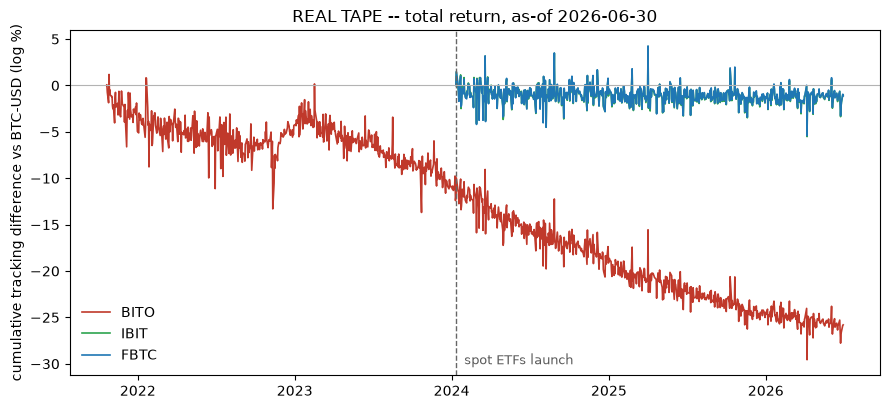

In [9]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath(os.path.join('..','..','..')))
import matplotlib.pyplot as plt
import pandas as pd
from etf_basis import data, strategy as st
if not data.have_real():
    print('real cache absent -- chart skipped (no synthetic substitute under a real banner)')
else:
    px = data.load_prices()
    fig, ax = plt.subplots(figsize=(9, 4.2))
    for tk, colour in [('BITO', '#c0392b'), ('IBIT', '#2ea44f'), ('FBTC', '#1f77b4')]:
        c = st.cumulative_diff(px[tk].dropna(), px['BTC-USD'].dropna()) * 100
        ax.plot(c.index, c.values, color=colour, lw=1.2, label=tk)
    ax.axvline(pd.Timestamp(data.LAUNCH), color='0.4', ls='--', lw=1)
    ax.annotate('spot ETFs launch', xy=(pd.Timestamp(data.LAUNCH), ax.get_ylim()[0]),
                xytext=(6, 8), textcoords='offset points', color='0.35', fontsize=9)
    ax.axhline(0, color='0.7', lw=0.8)
    ax.set_ylabel('cumulative tracking difference vs BTC-USD (log %)')
    ax.set_title('REAL TAPE -- total return, as-of 2026-06-30')
    ax.legend(loc='lower left', frameon=False)
    fig.tight_layout()
    plt.show()

> 💡 **In plain words.** The green and blue lines (spot ETFs) are nearly flat — they cost you their fee and nothing else. The red line (futures ETF) walks steadily downhill, and its slope does not kink at the dashed launch line.

## 6. Tradability — long IBIT / short BITO

Equal notional, reset every 21 sessions. **The single execution lag:** the reset uses the close of day *t* and is live from *t+1*; between resets the weights drift with the legs. The short leg pays borrow (an ASSUMPTION, swept) every day it is on; both legs pay one-way cost × NAV on the notional traded at each reset.

**Financing (an ASSUMPTION).** The book is dollar-neutral and self-financing — the short proceeds pay for the long leg and the rebate on them is assumed to offset the cash the long leg gives up — so what follows is already **excess of cash on both legs**, with no risk-free rate left to subtract. `borrow` is the *incremental* loan fee on top of that wash, which is why the 5% row matters: it is the world where the rebate collapses.

In [10]:
print(f"{'borrow':>7} {'net %/yr':>10} {'Sharpe':>8} {'HAC t':>8}")
for lbl, ann, sh, t in [('0%', R['h0'], R['h0_sharpe'], R['h0_t']),
                        ('1%', R['h1'], R['h1_sharpe'], R['h1_t']),
                        ('2%', R['h2'], R['h2_sharpe'], R['h2_t']),
                        ('5%', R['h5'], R['h5_sharpe'], R['h5_t'])]:
    print(f"{lbl:>7} {ann:10.2f} {sh:8.2f} {t:8.2f}")
print(f"\nat 2% borrow / 5 bps: vol {R['h2_vol']:.2f}%, worst DD {R['h2_dd']:.2f}%, "
      f"bootstrap Sharpe CI [{R['boot_sh_lo']:+.2f}, {R['boot_sh_hi']:+.2f}]")
print(f"  inference cross-checks: HAC(250) t {R['h2_t250']:+.2f}; non-overlapping "
      f"monthly t {R['h2_mo_t']:+.2f} ({R['h2_mo_pos']} months positive)")
print(f"FBTC as the long leg: {R['fbtc_pair']:+.2f}%/yr net (t {R['fbtc_pair_t']:+.2f})")
print(f"\nby year (2% borrow, 5 bps): gross {R['yr24_gross']:+.2f}/{R['yr25_gross']:+.2f}/{R['yr26_gross']:+.2f}%  "
      f"net {R['yr24_net']:+.2f}/{R['yr25_net']:+.2f}/{R['yr26_net']:+.2f}%  (2024/2025/2026H1)")

 borrow   net %/yr   Sharpe    HAC t
     0%       5.39     2.83     7.31
     1%       4.27     2.25     5.81
     2%       3.28     1.72     4.47
     5%       0.30     0.16     0.41

at 2% borrow / 5 bps: vol 1.90%, worst DD -0.67%, bootstrap Sharpe CI [+0.95, +2.48]
  inference cross-checks: HAC(250) t +3.74; non-overlapping monthly t +4.35 (28/30 months positive)
FBTC as the long leg: +3.20%/yr net (t +4.31)

by year (2% borrow, 5 bps): gross +6.67/+5.29/+3.06%  net +4.50/+3.22/+0.99%  (2024/2025/2026H1)


## 7. Synthetic control — the machinery is unbiased

**Synthetic data, not the real tape.** A planted world: a spot wrapper bleeding a known fee, a futures wrapper bleeding `fee + basis − collateral`, and every wrapper close stamped at a different hour from the reference. The detector must recover a planted compression *and* stay quiet when the carry is large but unchanged — the exact failure mode that would have manufactured our headline.

In [11]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath(os.path.join('..','..','..')))
import numpy as np
from etf_basis import data, strategy as st
pl = st.synthetic_detect(*data.synthetic_panel(signal_strength=1.0, seed=958))
nl = st.synthetic_detect(*data.synthetic_panel(signal_strength=0.0, seed=958))
print(f"SYNTHETIC ruler : planted fee {nl['planted_fee_pct']:+.2f}%/yr -> reads {nl['spot_etf_drag_pct']:+.3f}%/yr")
print(f"SYNTHETIC planted compression {pl['planted_change_pct']:+.2f} pp -> reads "
      f"{pl['era_change_pct']:+.2f} pp (t {pl['era_t']:+.2f})")
print(f"SYNTHETIC null (same big carry, no break) -> reads "
      f"{nl['era_change_pct']:+.2f} pp (t {nl['era_t']:+.2f})")
nulls = np.array([st.synthetic_detect(*data.synthetic_panel(signal_strength=0.0, seed=958+s))['era_change_pct']
                  for s in range(8)])
print(f"SYNTHETIC null x8 seeds: mean {nulls.mean():+.2f} pp (sd {nulls.std(ddof=1):.2f}), "
      f"|change| >= 2 pp in {(np.abs(nulls) >= 2.0).sum()}/8")
print(f"SYNTHETIC endpoint estimator on the same world: {nl['fut_drag_naive_pct']:+.2f}%/yr "
      f"vs trend {nl['fut_drag_trend_pct']:+.2f}%/yr")

SYNTHETIC ruler : planted fee -0.25%/yr -> reads -0.285%/yr
SYNTHETIC planted compression +7.00 pp -> reads +7.31 pp (t +33.21)
SYNTHETIC null (same big carry, no break) -> reads +0.31 pp (t +1.43)


SYNTHETIC null x8 seeds: mean +0.09 pp (sd 0.22), |change| >= 2 pp in 0/8
SYNTHETIC endpoint estimator on the same world: -5.21%/yr vs trend -5.49%/yr


## Verdict

- **Signal — Mixed.** The futures carry is still there at Real-grade strength, and it is the **matched-close** measure that certifies it: -5.72%/yr against IBIT, holding on every estimator including non-overlapping monthly gaps with no HAC at all (*t* = -9.83; endpoint *t* = -7.24; the trend *t* = -30.7 is reported but discounted — that residual is near a unit root, DF *t* = -3.00). Against the coin it reads -5.97%/yr (trend *t* = -29.3, -17.7 at 250 lags — but only -2.17 monthly: sixteen hours of bitcoin sits in that ruler). An implied front basis of +9.4%/yr, +5.0%/yr above cash — on a ruler calibrated to read a 25 bp fee exactly. The **compression claim is rejected**: matched twelve-month windows read -7.32 vs -7.35%/yr (change -0.04 pp, *t* = -0.08) — and **no** symmetric width from ±6 to ±24 months compresses, several being significantly wrong-signed, so the answer does not turn on the window (though ±12m is the flattest member of that family and is labelled as such); the full-sample break is wrong-signed and ranks 7/44 against placebo dates; the gradual 2025-26 fade tracks the bitcoin cycle (corr -0.32, *t* = -1.89 — suggestive only). Synthetic control fires on a planted break (+7.31 pp, *t* = 33.2) and is silent on the null (mean +0.09 pp, 0/8). No survivorship — three continuously listed instruments — though BITO is the *surviving* futures wrapper, so the class-wide toll is if anything understated.
- **Tradability — Fragile.** +3.28%/yr net at 2% borrow and 5 bps, excess of cash on both legs (Sharpe 1.72, *t* = +4.47, +3.74 at 250 lags, non-overlapping monthly *t* = +4.35, bootstrap CI [+0.95, +2.48], worst drawdown 0.67%), dead at 5% borrow (+0.30%/yr, *t* = +0.41), decaying year by year, and capacity-bounded by BITO's borrow pool. The riskless version — owning the spot wrapper — is cost avoidance, not alpha.